# Toy Experiment: Explanatory Note and Result Display


## 1. Objective

The current experiment compares Classic inference, Naive ML, PPI, PPI++V1, and PPI++V2 under three statistical settings: mean estimation, linear regression, and logistic GLM. The comparison is conducted from the perspective of learner quality, with empirical coverage and confidence-interval width used as the main inferential-performance metrics.


## 2. Formulation

### 2.1 PPI

For mean estimation, PPI uses

$$
\widehat\theta_{\mathrm{PPI}}
=
\frac{1}{n}\sum_{i=1}^{n}Y_i
+
\left(
\frac{1}{N}\sum_{j=1}^{N}f(X_j^u)
-
\frac{1}{n}\sum_{i=1}^{n}f(X_i)
\right).
$$

The first term uses labelled data, while the bracketed term uses unlabelled predictions and labelled correction. For linear regression and logistic GLM, the same idea is implemented at the estimating-equation level.

### 2.2 PPI++V1

PPI++V1 can be written as

$$
\widehat\theta_{\mathrm{PPI++V1}}
=
\frac{1}{n}\sum_{i=1}^{n}Y_i
+
\widehat\lambda_{\mathrm{py}}
\left(
\frac{1}{N}\sum_{j=1}^{N}f(X_j^u)
-
\frac{1}{n}\sum_{i=1}^{n}f(X_i)
\right),
$$

where $\widehat\lambda_{\mathrm{py}}$ is the package-selected power-tuning parameter returned internally when `lam=None`.

For a fixed $\lambda$, the weighted estimating equation has the form

$$
0
=
\frac{1}{n}
\sum_{i=1}^{n}
\left\{
\psi_i^Y(\theta)
-
\lambda \psi_i^{\hat Y}(\theta)
\right\}
+
\frac{\lambda}{N}
\sum_{j=1}^{N}
\psi_j^{\hat Y,U}(\theta).
$$

PPI++V1 chooses $\lambda$ using the package's internal optimal-lambda rule. Define the centered score matrices

$$
G_c = G-\bar G,
\qquad
\widehat G_c = \widehat G-\bar{\widehat G},
$$

where $G$ collects the labelled true-label score contributions $\psi_i^Y$, and $\widehat G$ collects the labelled prediction score contributions $\psi_i^{\hat Y}$. The package forms

$$
\widehat C
=
\frac{1}{n}
\left(
G_c^\top \widehat G_c
+
\widehat G_c^\top G_c
\right).
$$

It also forms a prediction-score covariance matrix by combining the labelled and unlabelled prediction-score contributions:

$$
\widehat S
=
\widehat{\operatorname{Cov}}
\left(
\begin{bmatrix}
\widehat G \\
\widehat G^{U}
\end{bmatrix}
\right),
$$

where $\widehat G^{U}$ collects the unlabelled prediction-powered score contributions $\psi_j^{\hat Y,U}$.

Let $\widehat H^{-1}$ be the inverse empirical Hessian or Jacobian used for the corresponding estimating equation. With `coord=None`, PPI++V1 optimizes the total variance over all coordinates and computes

$$
\widehat\lambda_{\mathrm{py}}
=
\Pi_{[0,1]}
\left[
\frac{
\operatorname{tr}
\left(
\widehat H^{-1}
\widehat C
\widehat H^{-T}
\right)
}{
2(1+n/N)
\operatorname{tr}
\left(
\widehat H^{-1}
\widehat S
\widehat H^{-T}
\right)
}
\right],
$$

where $\Pi_{[0,1]}(\cdot)$ denotes clipping to the interval $[0,1]$.

For mean estimation, $\widehat H^{-1}=I$. In this case, the score contributions reduce to centered versions of $Y_i$, $f(X_i)$, and $f(X_j^u)$ around the preliminary PPI point estimate.

For linear regression and logistic GLM, the same formula is applied to the corresponding score or gradient contributions.

Toyv3 requests package-native 90%, 95%, and 97.5% intervals separately from `ppi-python`; formal coverage and width use those direct intervals. A 95% diagonal covariance reconstruction is retained only for compatibility. If the package returns $[L_k,U_k]$ at level $c$, then

$$
z_c
=
\Phi^{-1}
\left(
\frac{1+c}{2}
\right),
$$

$$
\widehat{\mathrm{se}}_k
=
\frac{U_k-L_k}{2z_c},
$$

and toyv3 constructs

$$
\widehat V_{\mathrm{PPI++V1}}
=
\operatorname{diag}
\left(
\widehat{\mathrm{se}}_1^2,
\ldots,
\widehat{\mathrm{se}}_p^2
\right).
$$

This diagonal covariance is not used for formal CI width or coverage. With `lam=None`, lambda is selected internally and is not exposed by the package API.


### 2.3 PPI++V2

PPI++V2 is the internal variance-minimizing weighted PPI implementation used in this toy experiment. It is not the package-standard PPI++ reference.

For mean estimation, PPI++V2 considers a weighted PPI estimator indexed by $\lambda\in[0,1]$:

$$
\widehat\theta_{\lambda}
=
\frac{1}{n}\sum_{i=1}^{n}Y_i
+
\lambda
\left(
\frac{1}{N}\sum_{j=1}^{N}f(X_j^u)
-
\frac{1}{n}\sum_{i=1}^{n}f(X_i)
\right).
$$

For a fixed $\lambda$, the variance estimator in the mean-estimation case is

$$
\widehat{\operatorname{Var}}(\widehat\theta_{\lambda})
=
\frac{
\widehat{\operatorname{Var}}\{Y_i-\lambda f(X_i)\}_{i=1}^{n}
}{n}
+
\lambda^2
\frac{
\widehat{\operatorname{Var}}\{f(X_j^u)\}_{j=1}^{N}
}{N}.
$$

This variance has two parts. The first term is the labelled correction uncertainty. It is not only the variance of the true labels. It also contains the variance of the learner output and the covariance between the true label and the learner output, because

$$
\operatorname{Var}\{Y-\lambda f(X)\}
=
\operatorname{Var}(Y)
+
\lambda^2\operatorname{Var}\{f(X)\}
-
2\lambda\operatorname{Cov}\{Y,f(X)\}.
$$

The second term is the uncertainty from the unlabelled prediction-powered component. It depends on the variation of $f(X^u)$ on the unlabelled sample and is scaled by $\lambda^2$.

For linear regression and logistic GLM, toyv3 computes the same idea through a sandwich covariance matrix,

$$
\widehat V_\lambda
=
\widehat H_\lambda^{-1}
\widehat\Omega_\lambda
\widehat H_\lambda^{-T}.
$$

PPI++V2 searches over the grid $\Lambda=\texttt{PPI\_PLUS\_PLUS\_V2\_LAMBDA\_GRID}$ and selects

$$
\widehat{\lambda}
=
\arg\min_{\lambda\in\Lambda}
\operatorname{tr}
\left(
\widehat V_\lambda
\right).
$$

For mean estimation, $\operatorname{tr}(\widehat V_\lambda)$ is the scalar estimated variance. For linear regression and logistic GLM, $\widehat V_\lambda$ is a covariance matrix for all coefficients, so the trace criterion minimizes the sum of estimated coefficient variances.

This is a vector-level variance criterion. It can reduce the overall covariance trace, but it does not guarantee a shorter confidence interval for every individual coefficient in every replicate.


## 3. Toy Design

### 3.1 Data Settings

We consider three settings:

1. Mean estimation;
2. Linear regression;
3. Logistic GLM.

The covariates are generated as

$$
X=(1,X_1,X_2)^\top,
\qquad
X_1\sim U(-1,1),
\qquad
X_2\sim \mathrm{Bernoulli}(0.5).
$$

The common signal is

$$
\eta(X)=0.25+0.9X_1-0.6X_2.
$$

For mean estimation and linear regression,

$$
Y=\eta(X)+\epsilon,
\qquad
\epsilon\sim N(0,1).
$$

For logistic GLM,

$$
Y\mid X\sim\mathrm{Bernoulli}\{\operatorname{expit}(\eta(X))\}.
$$

The default sample sizes are $n=60$ labelled observations and $N=600$ unlabelled observations.

### 3.2 Learner-Quality Control

Learner quality is controlled through pseudo learner outputs rather than separately trained ML algorithms. For each scenario, let $z(X)$ be the true conditional mean. The proxy output is

$$
f(X)=z(X)+e(X).
$$

| Profile | Error structure | Interpretation |
|---|---:|---|
| P1 | Gaussian: $e=0.02Z$; logistic: $f=\operatorname{expit}(\eta+0.02Z)$, $Z\sim N(0,1)$ | small random error |
| P2 | $e=0.06$ | constant global bias |
| P3 | $e=0.06(2X_2-1)$ | random directions error |
| P4 | Gaussian: $e=0.20Z$; logistic: $f=\operatorname{expit}(\eta+0.20Z)$ | larger random error |

P1/P4 share the same standard-normal realization. Gaussian errors have a pointwise 10:1 ratio; logistic latent perturbations have that ratio, while reported error is on the probability scale. No clipping is used.

### 3.3 Compared Methods

| Method | Role |
|---|---|
| Classic | labelled-data-only inference |
| Naive ML | diagnostic baseline using predictions as if they were labels |
| PPI | prediction-powered inference with labelled correction |
| PPI++V1 | package-standard PPI++ reference using `ppi-python` with `lam=None` |
| PPI++V2 | internal variance-minimizing weighted PPI variant |

Naive ML is included only as a diagnostic baseline, because narrow intervals are not meaningful when coverage is invalid.


## 4. Outputs with Description

### 4.1 Main Metrics

The outputs are read through two main quantities: empirical coverage and confidence-interval width.

$$
\widehat{\mathrm{Coverage}}
=
\frac{1}{B}
\sum_{b=1}^{B}
\mathbf{1}\{\theta^\star\in CI^{(b)}\},
$$

$$
\widehat{\mathrm{Width}}
=
\frac{1}{B}
\sum_{b=1}^{B}
(U^{(b)}-L^{(b)}).
$$

| Quantity | Main question | How to read it |
|---|---|---|
| Empirical coverage | Is the interval valid? | It should be close to the nominal confidence level. |
| Average CI width | Is the interval efficient? | Smaller is better only when coverage remains valid. |

Two derived quantities are used in the figures and tables:

| Derived quantity | Definition | Use |
|---|---|---|
| Coverage error | $\widehat{\mathrm{Coverage}}-\text{nominal level}$ | Used in calibration figures; values closer to 0 are better. |
| Relative CI width | $\widehat{\mathrm{Width}}_{\mathrm{method}}/\widehat{\mathrm{Width}}_{\mathrm{Classic}}$ | Used to compare efficiency against Classic inference. |



## 5. Result Display


In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path("..").resolve() if Path.cwd().name == "ipy" else Path(".").resolve()
FULL = ROOT / "output" / "full"
FAST = ROOT / "output" / "fast"

if FULL.exists():
    OUT = FULL
elif FAST.exists():
    OUT = FAST
else:
    OUT = FULL

METHOD_LABELS = {
    "classic": "Classic",
    "naive_ml": "Naive ML",
    "ppi": "PPI",
    "ppi_plus_plus_v1": "PPI++V1",
    "ppi_plus_plus_v2": "PPI++V2",
}
SCENARIO_LABELS = {
    "mean": "Mean estimation",
    "lr": "Linear regression",
    "logistic_glm": "Logistic GLM",
}

display(Markdown(f"Using output directory: `{OUT}`"))


Using output directory: `D:\research\PPI\code\20260706\cityu\toyv3\output\full`

### 5.1 Main 95% Figures

The tables below keep only the columns needed to read the main 95% result.  
They are not intended to reproduce every raw output file.

For each row, read coverage first and width second.  
A smaller interval is useful only when empirical coverage remains close to the nominal level.

#### logistic_glm_main_cl_950.png

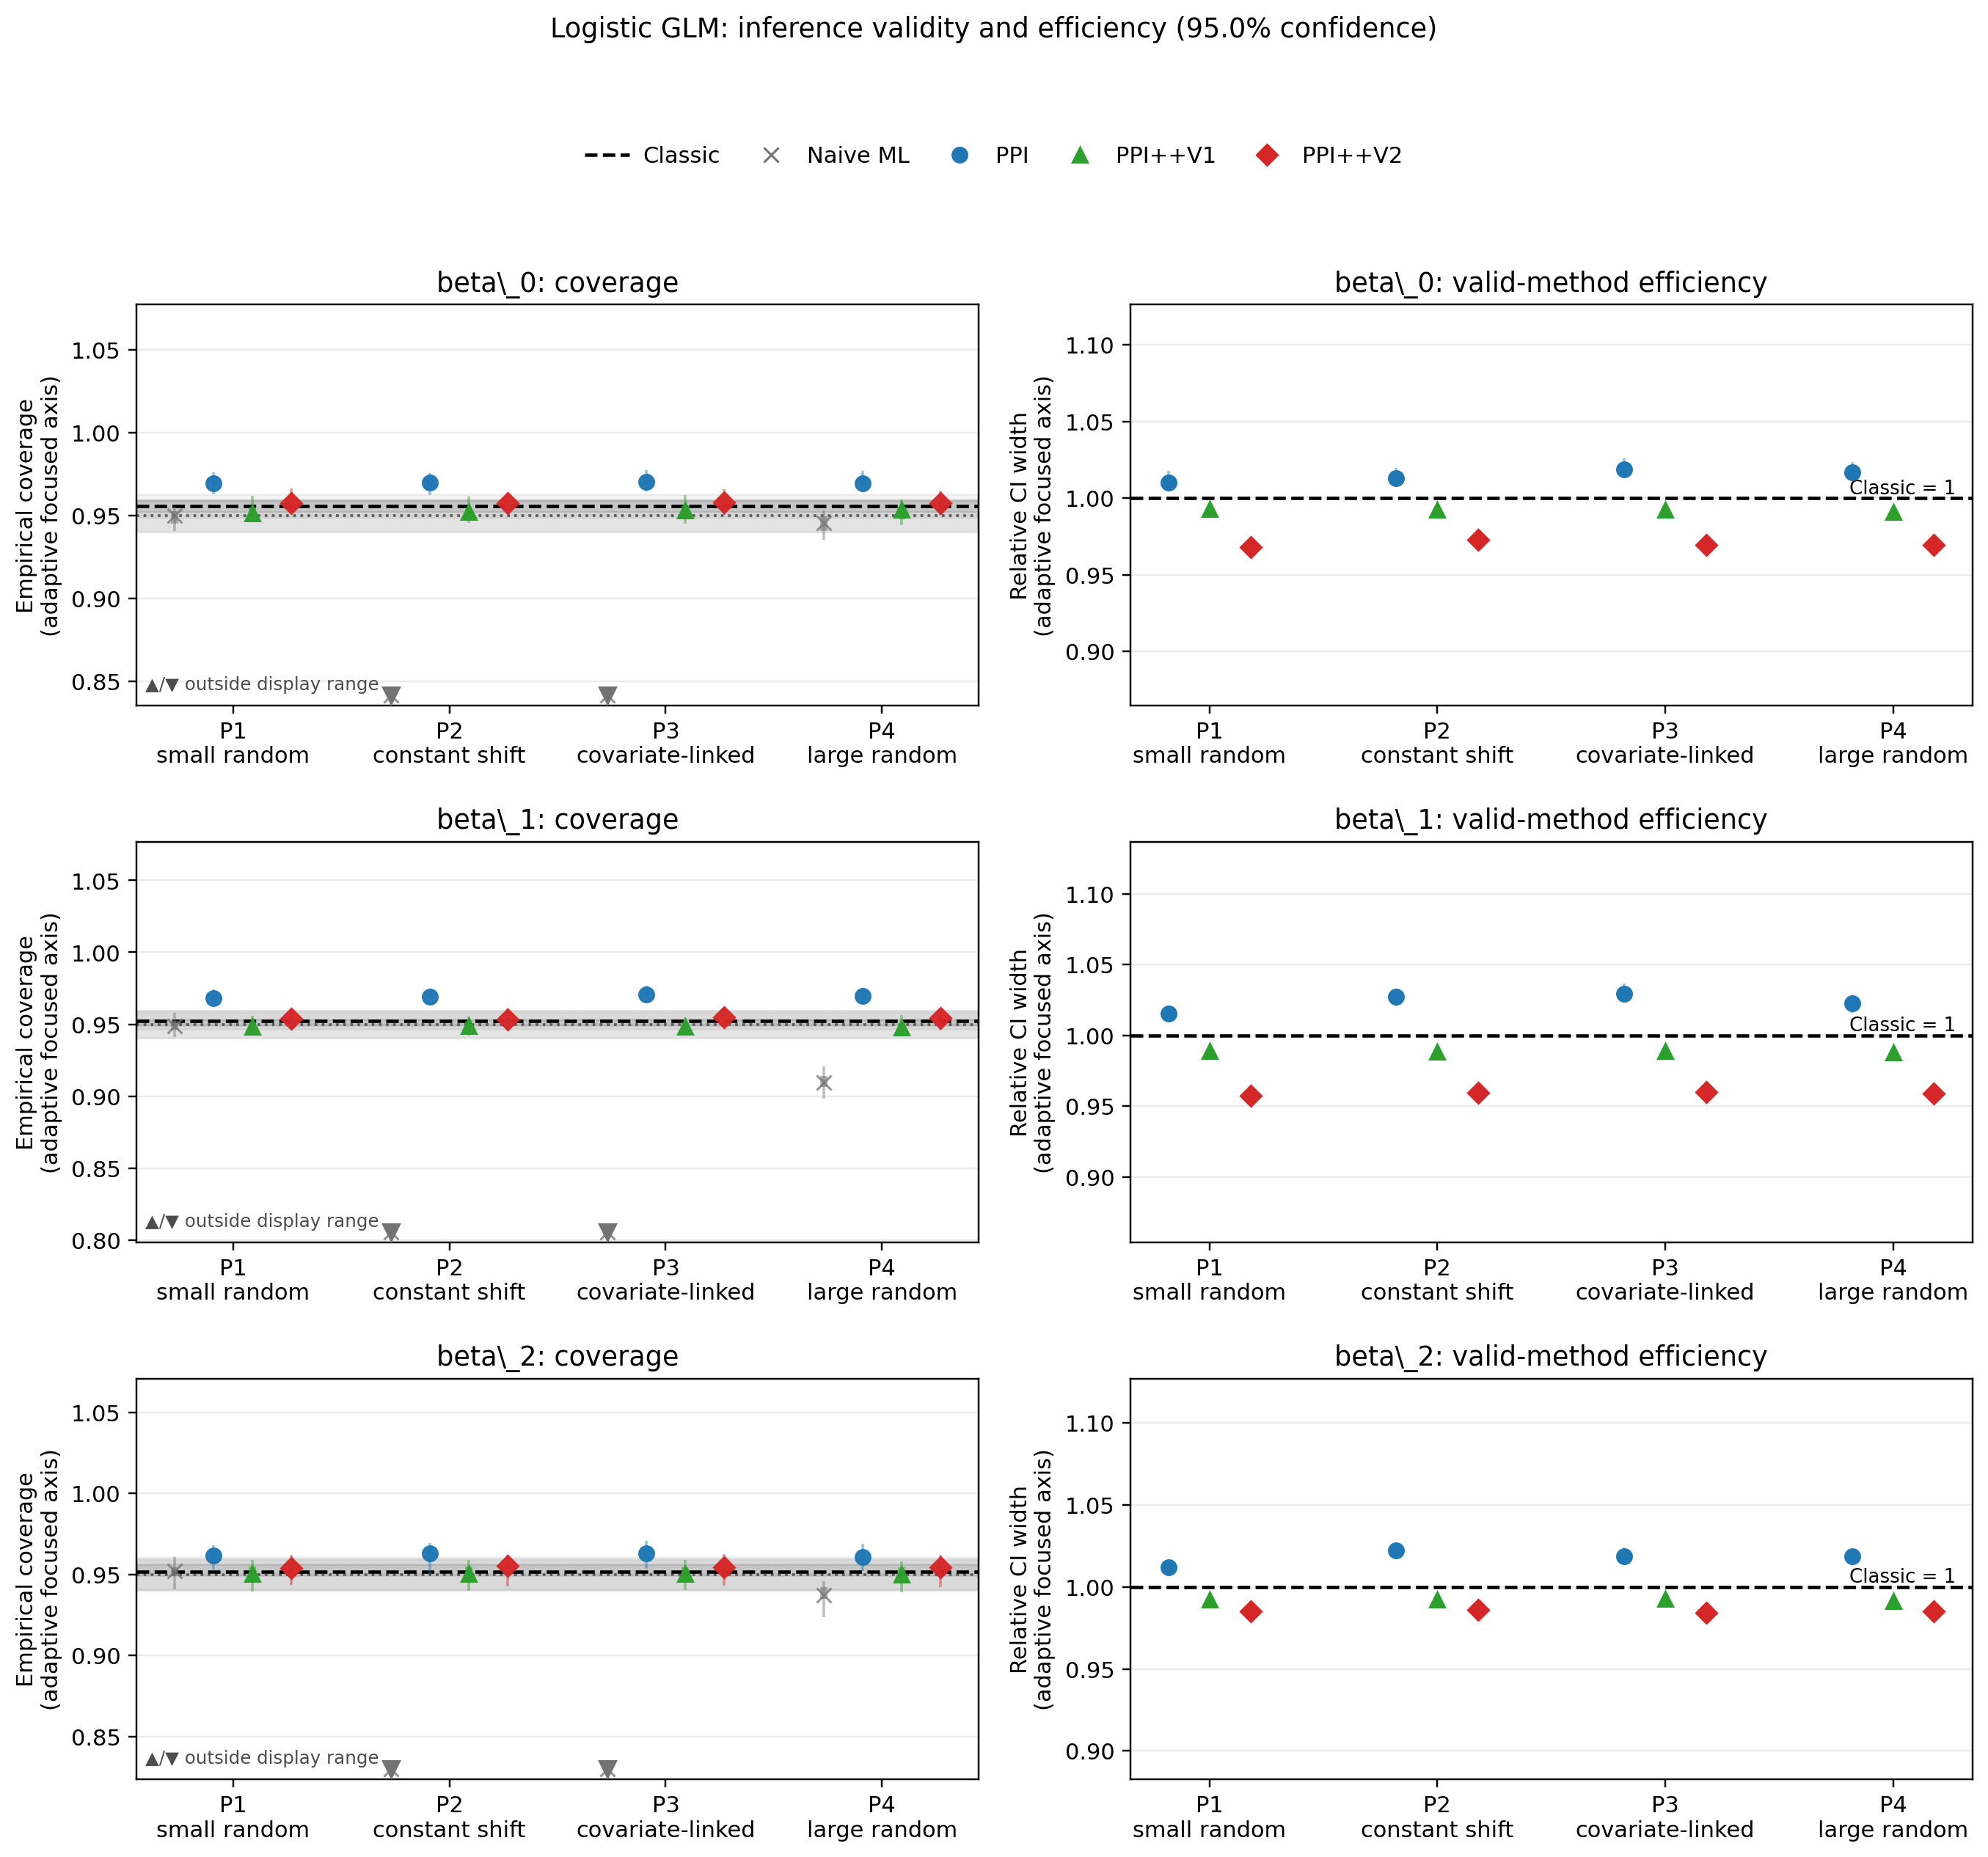

#### lr_main_cl_950.png

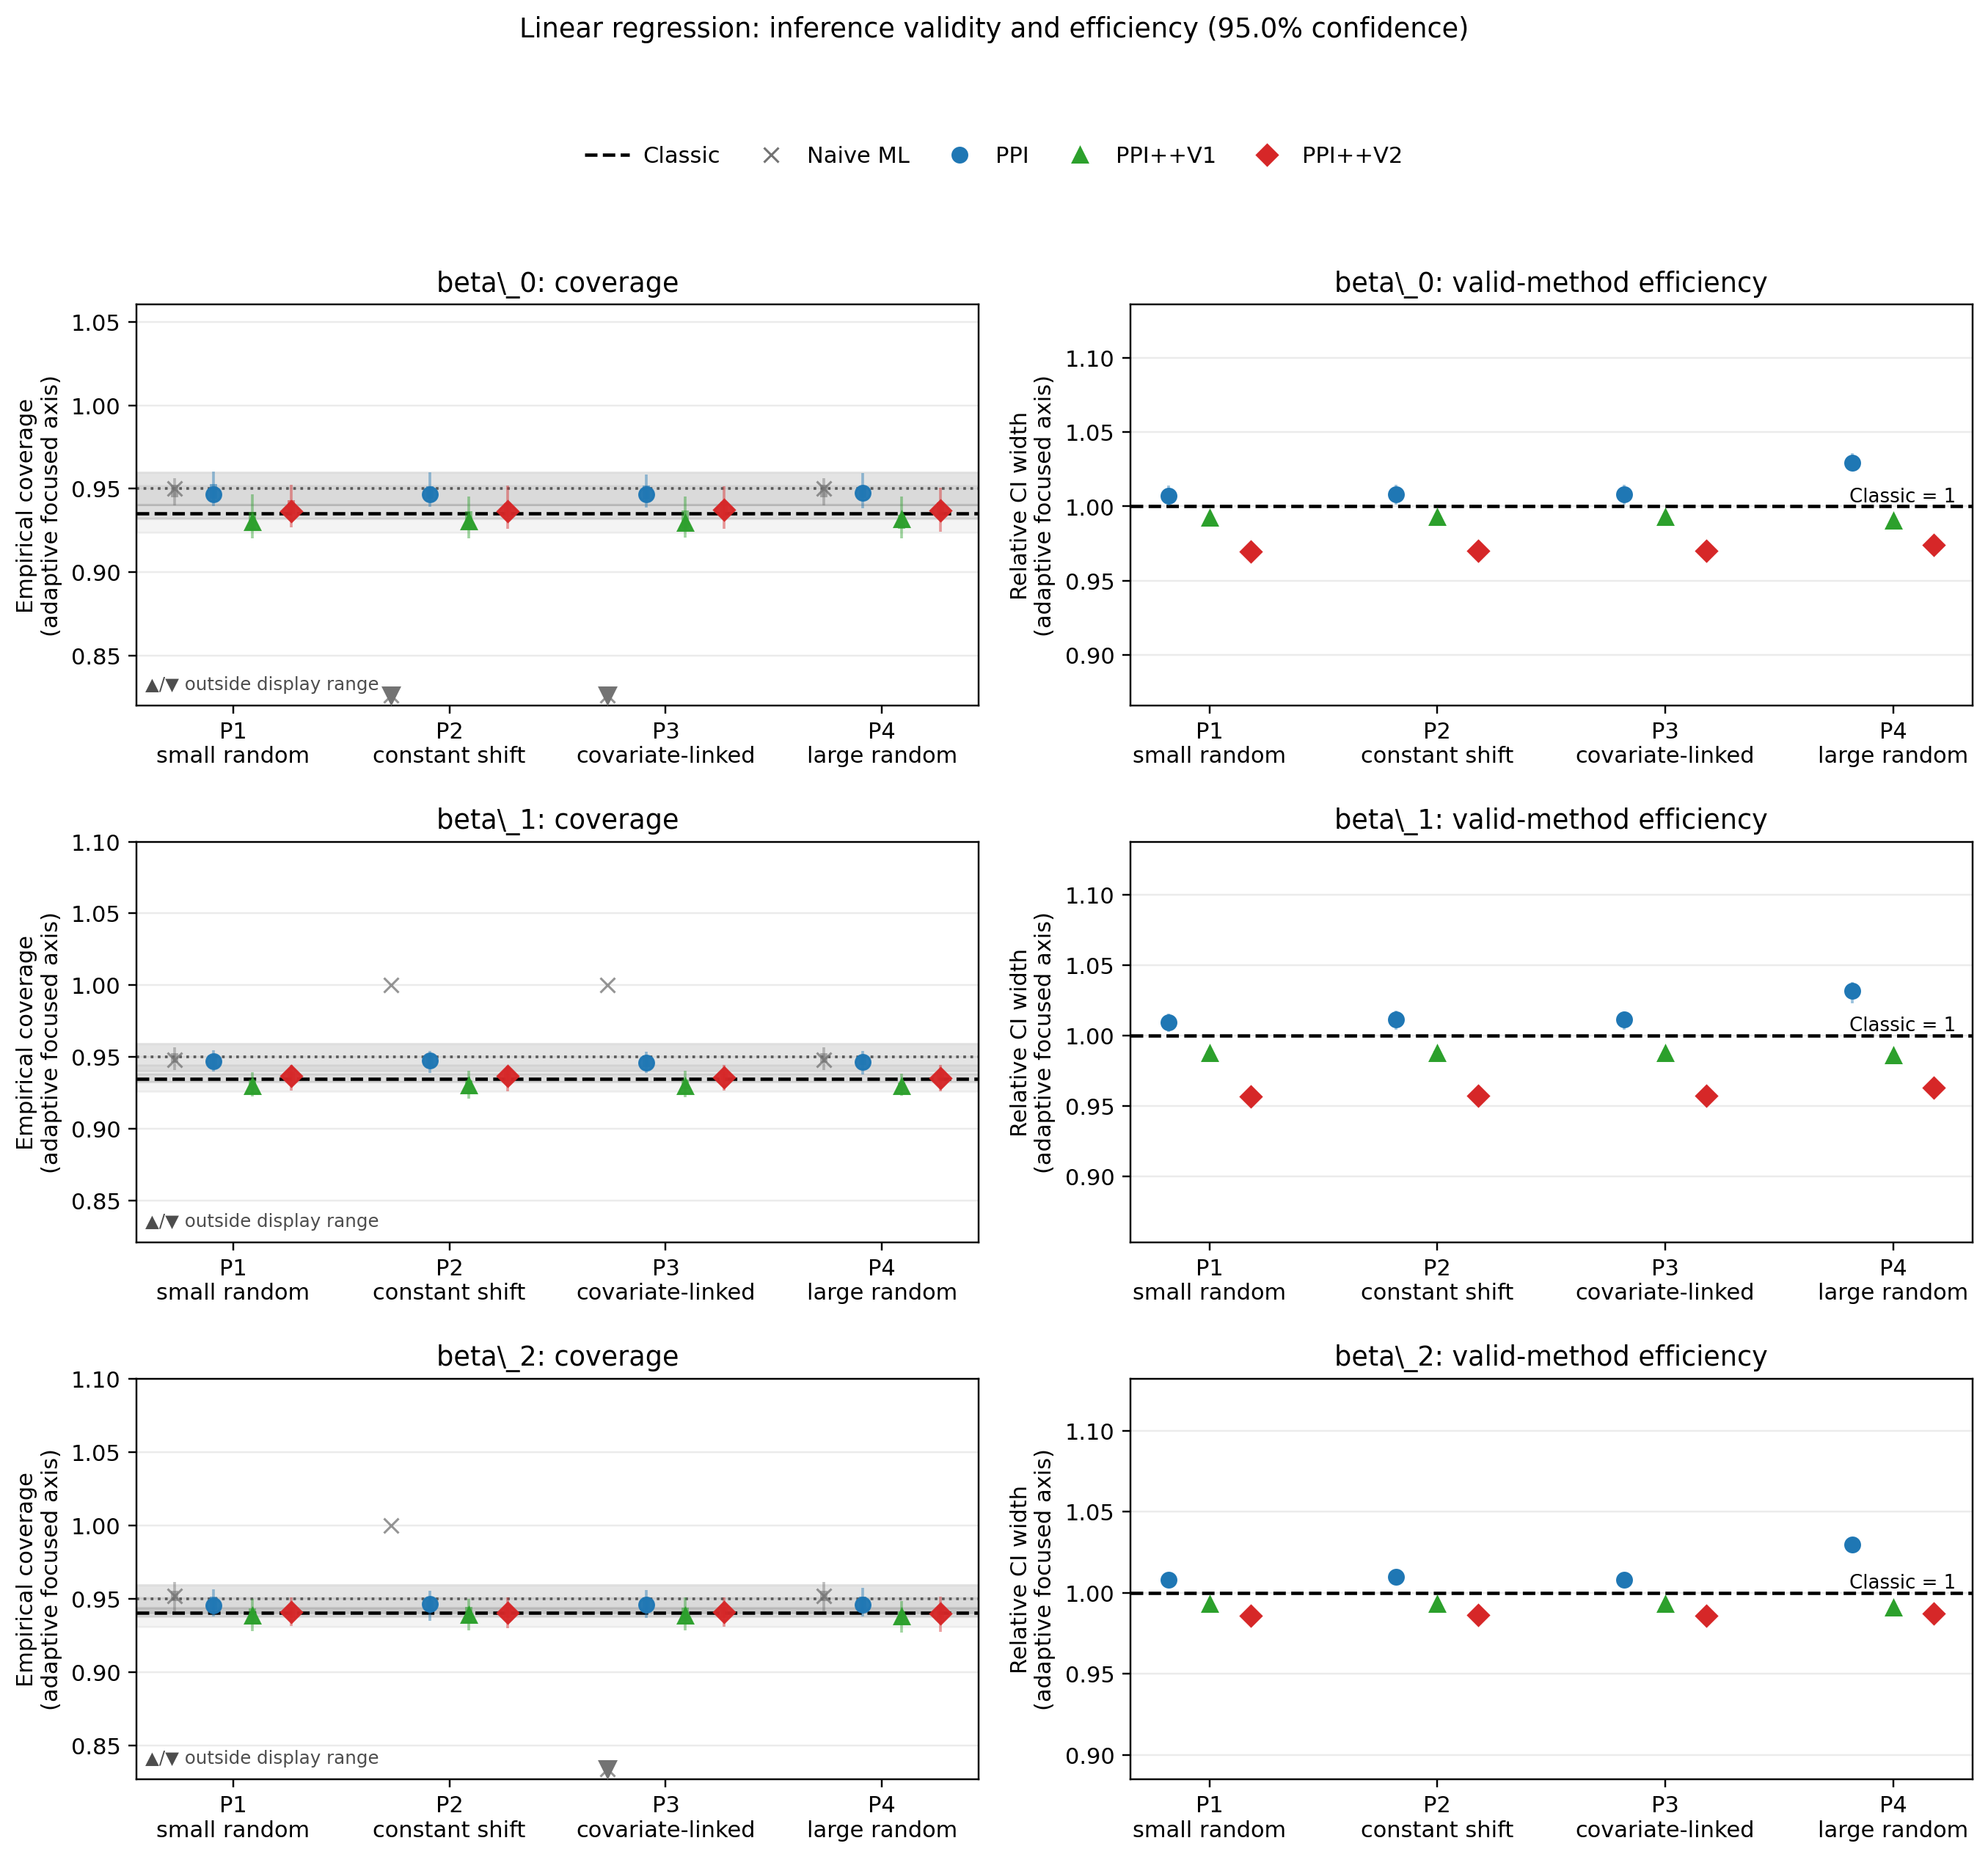

#### mean_main_cl_950.png

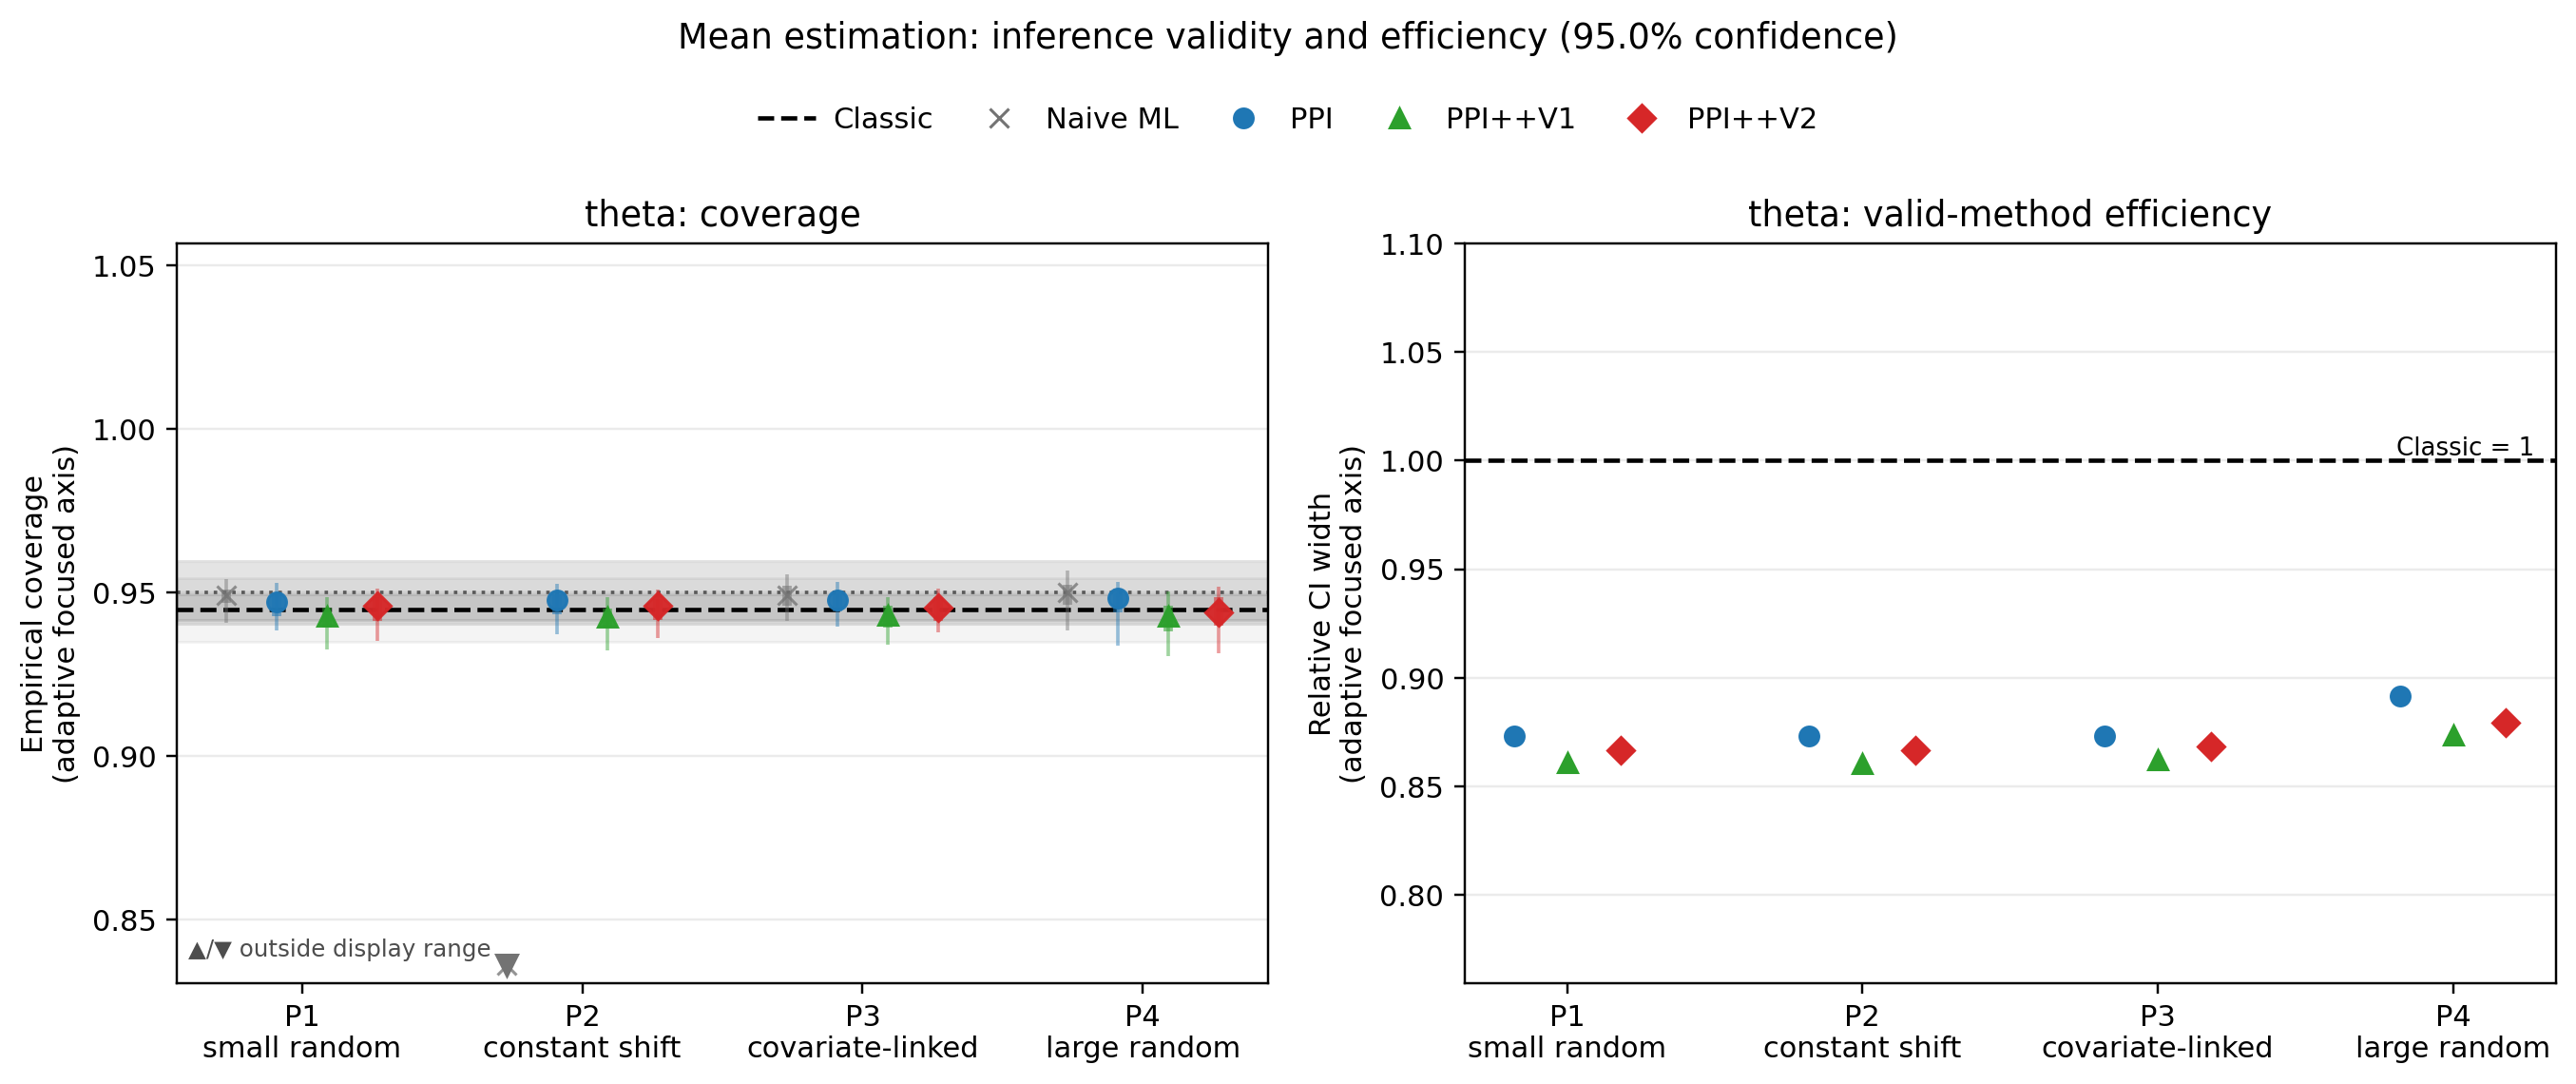

In [2]:
fig_dir = OUT / "figure"

if fig_dir.exists():
    figures = sorted([
        p for p in fig_dir.iterdir()
        if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".svg"]
    ])
    main_figs = [p for p in figures if "main_cl_950" in p.name]

    if not main_figs:
        display(Markdown("No main 95% figures found."))

    for p in main_figs:
        display(Markdown(f"#### {p.name}"))
        if p.suffix.lower() == ".svg":
            display(Markdown(f"[Open figure]({p.as_posix()})"))
        else:
            display(Image(filename=str(p)))
else:
    display(Markdown("No figure directory found."))


### 5.2 Calibration Figures


#### logistic_glm_calibration.png

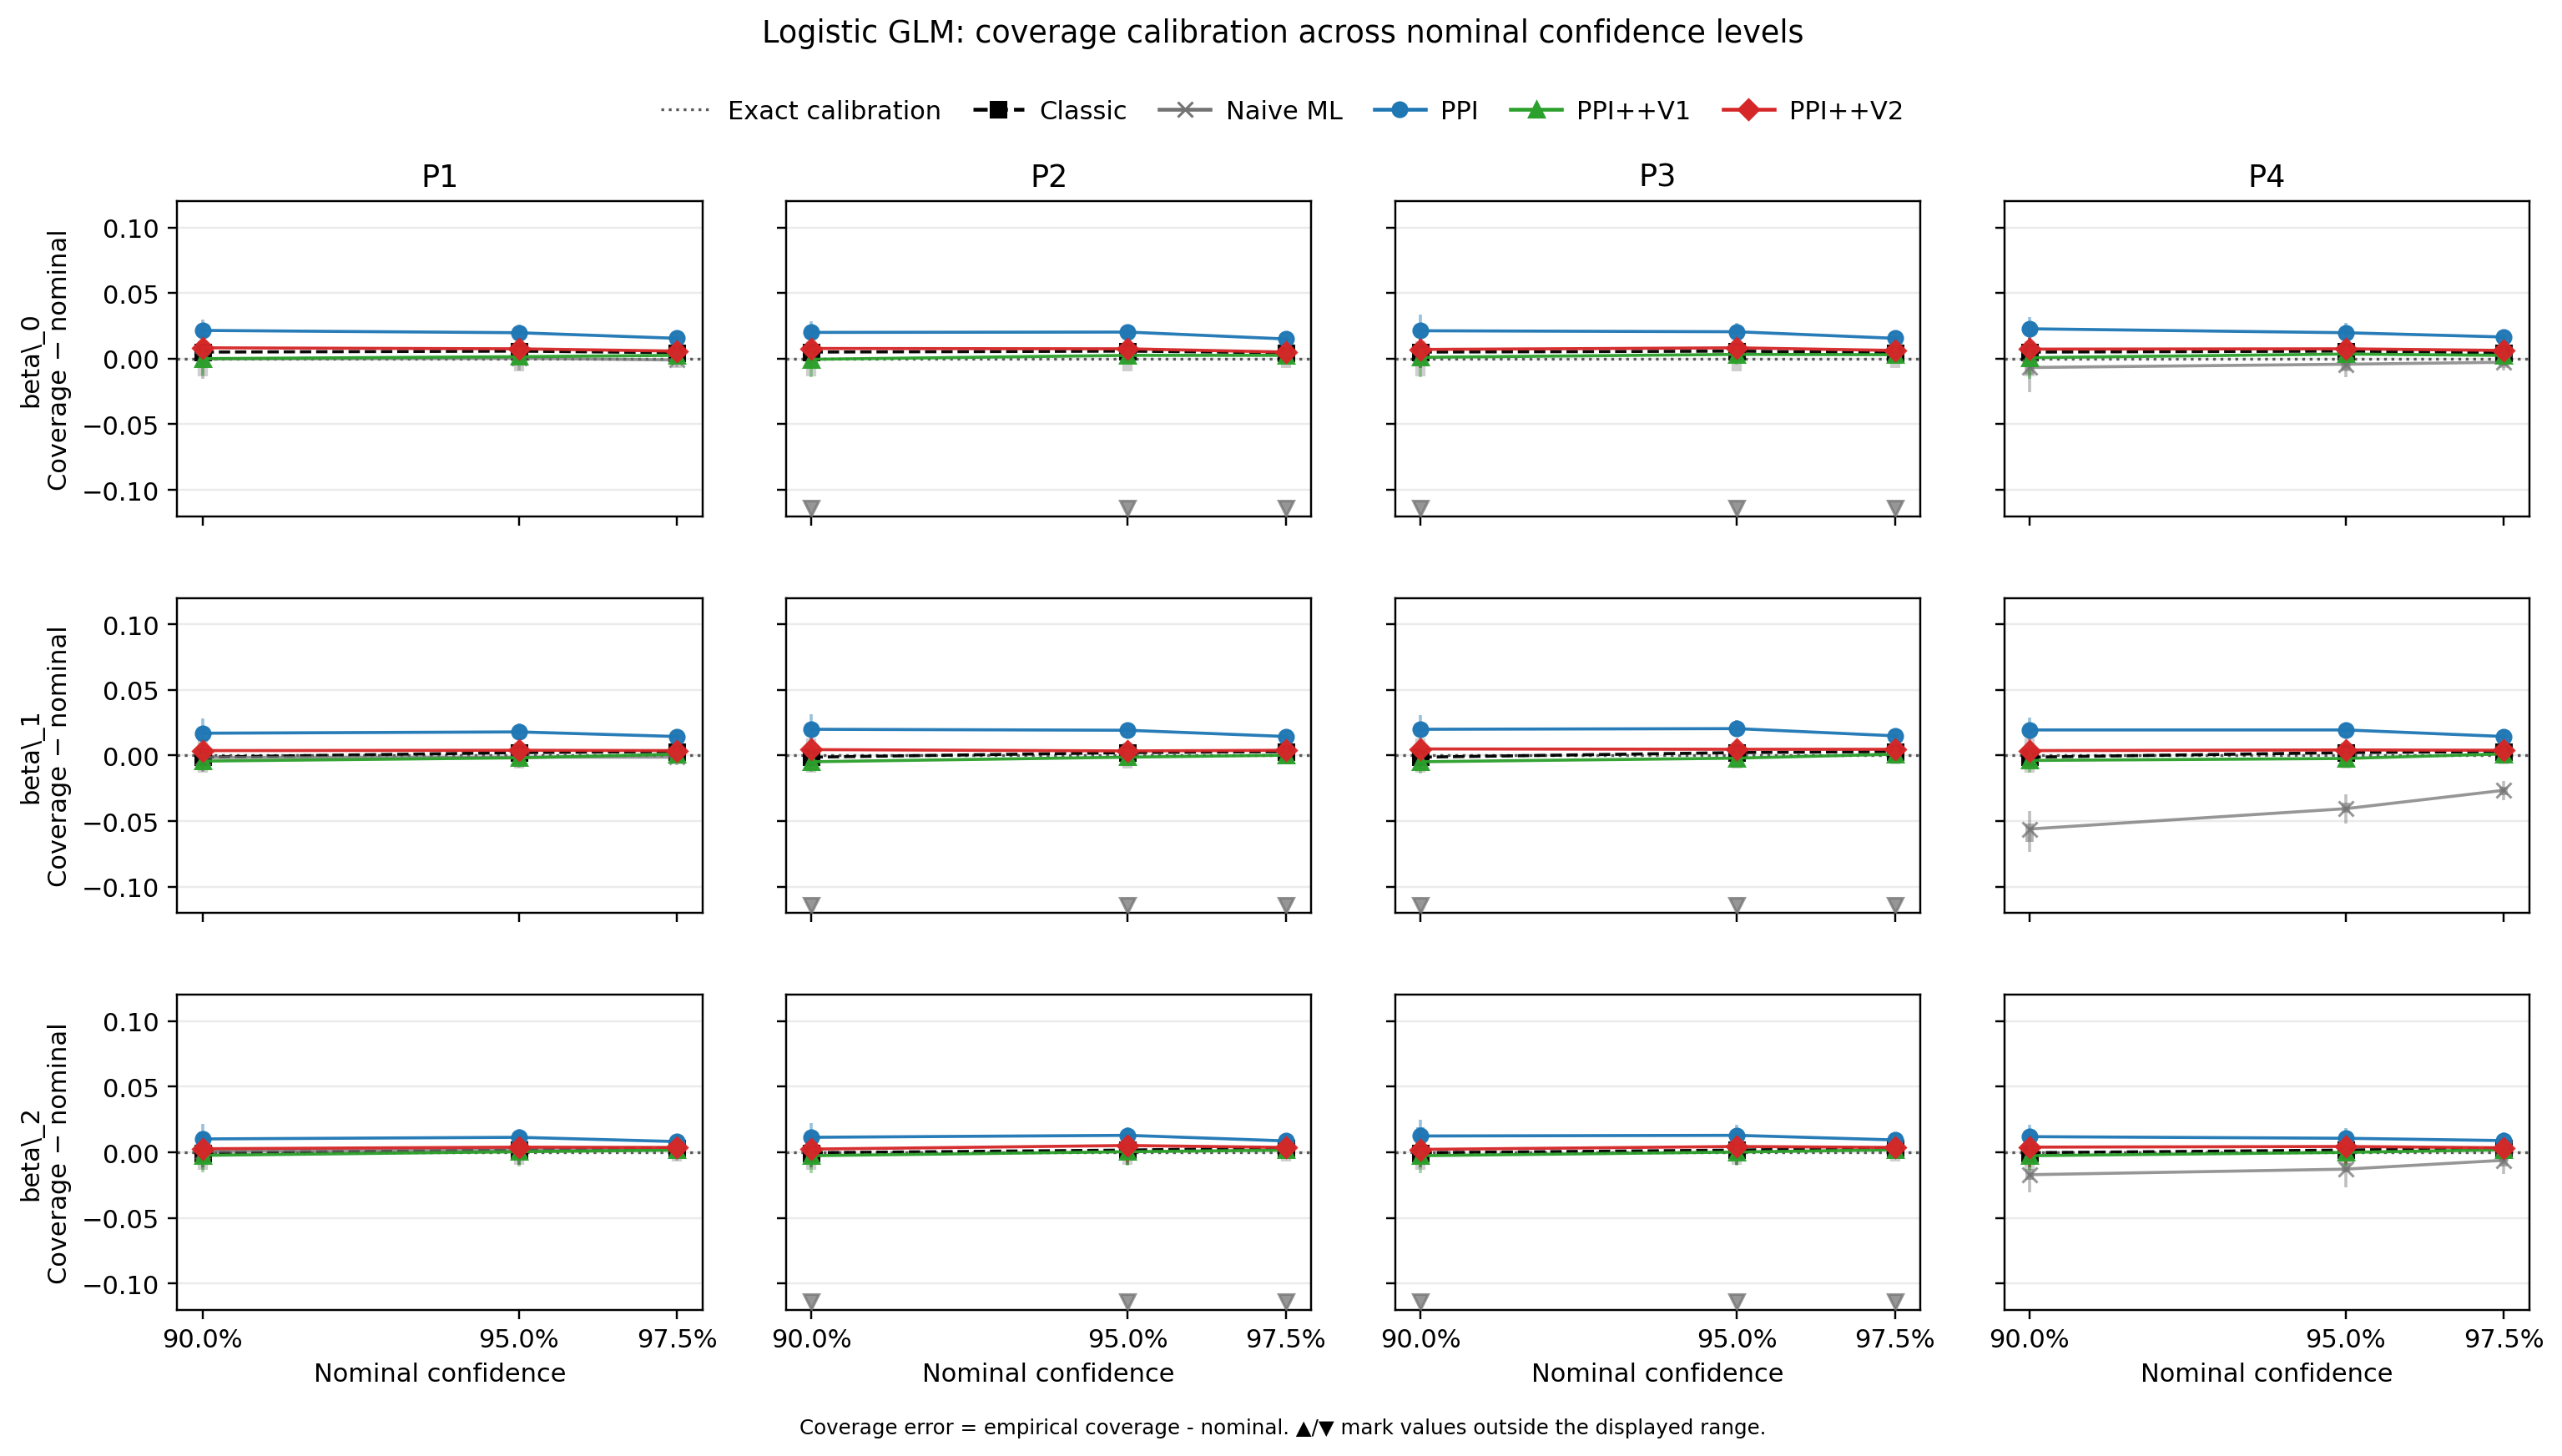

#### lr_calibration.png

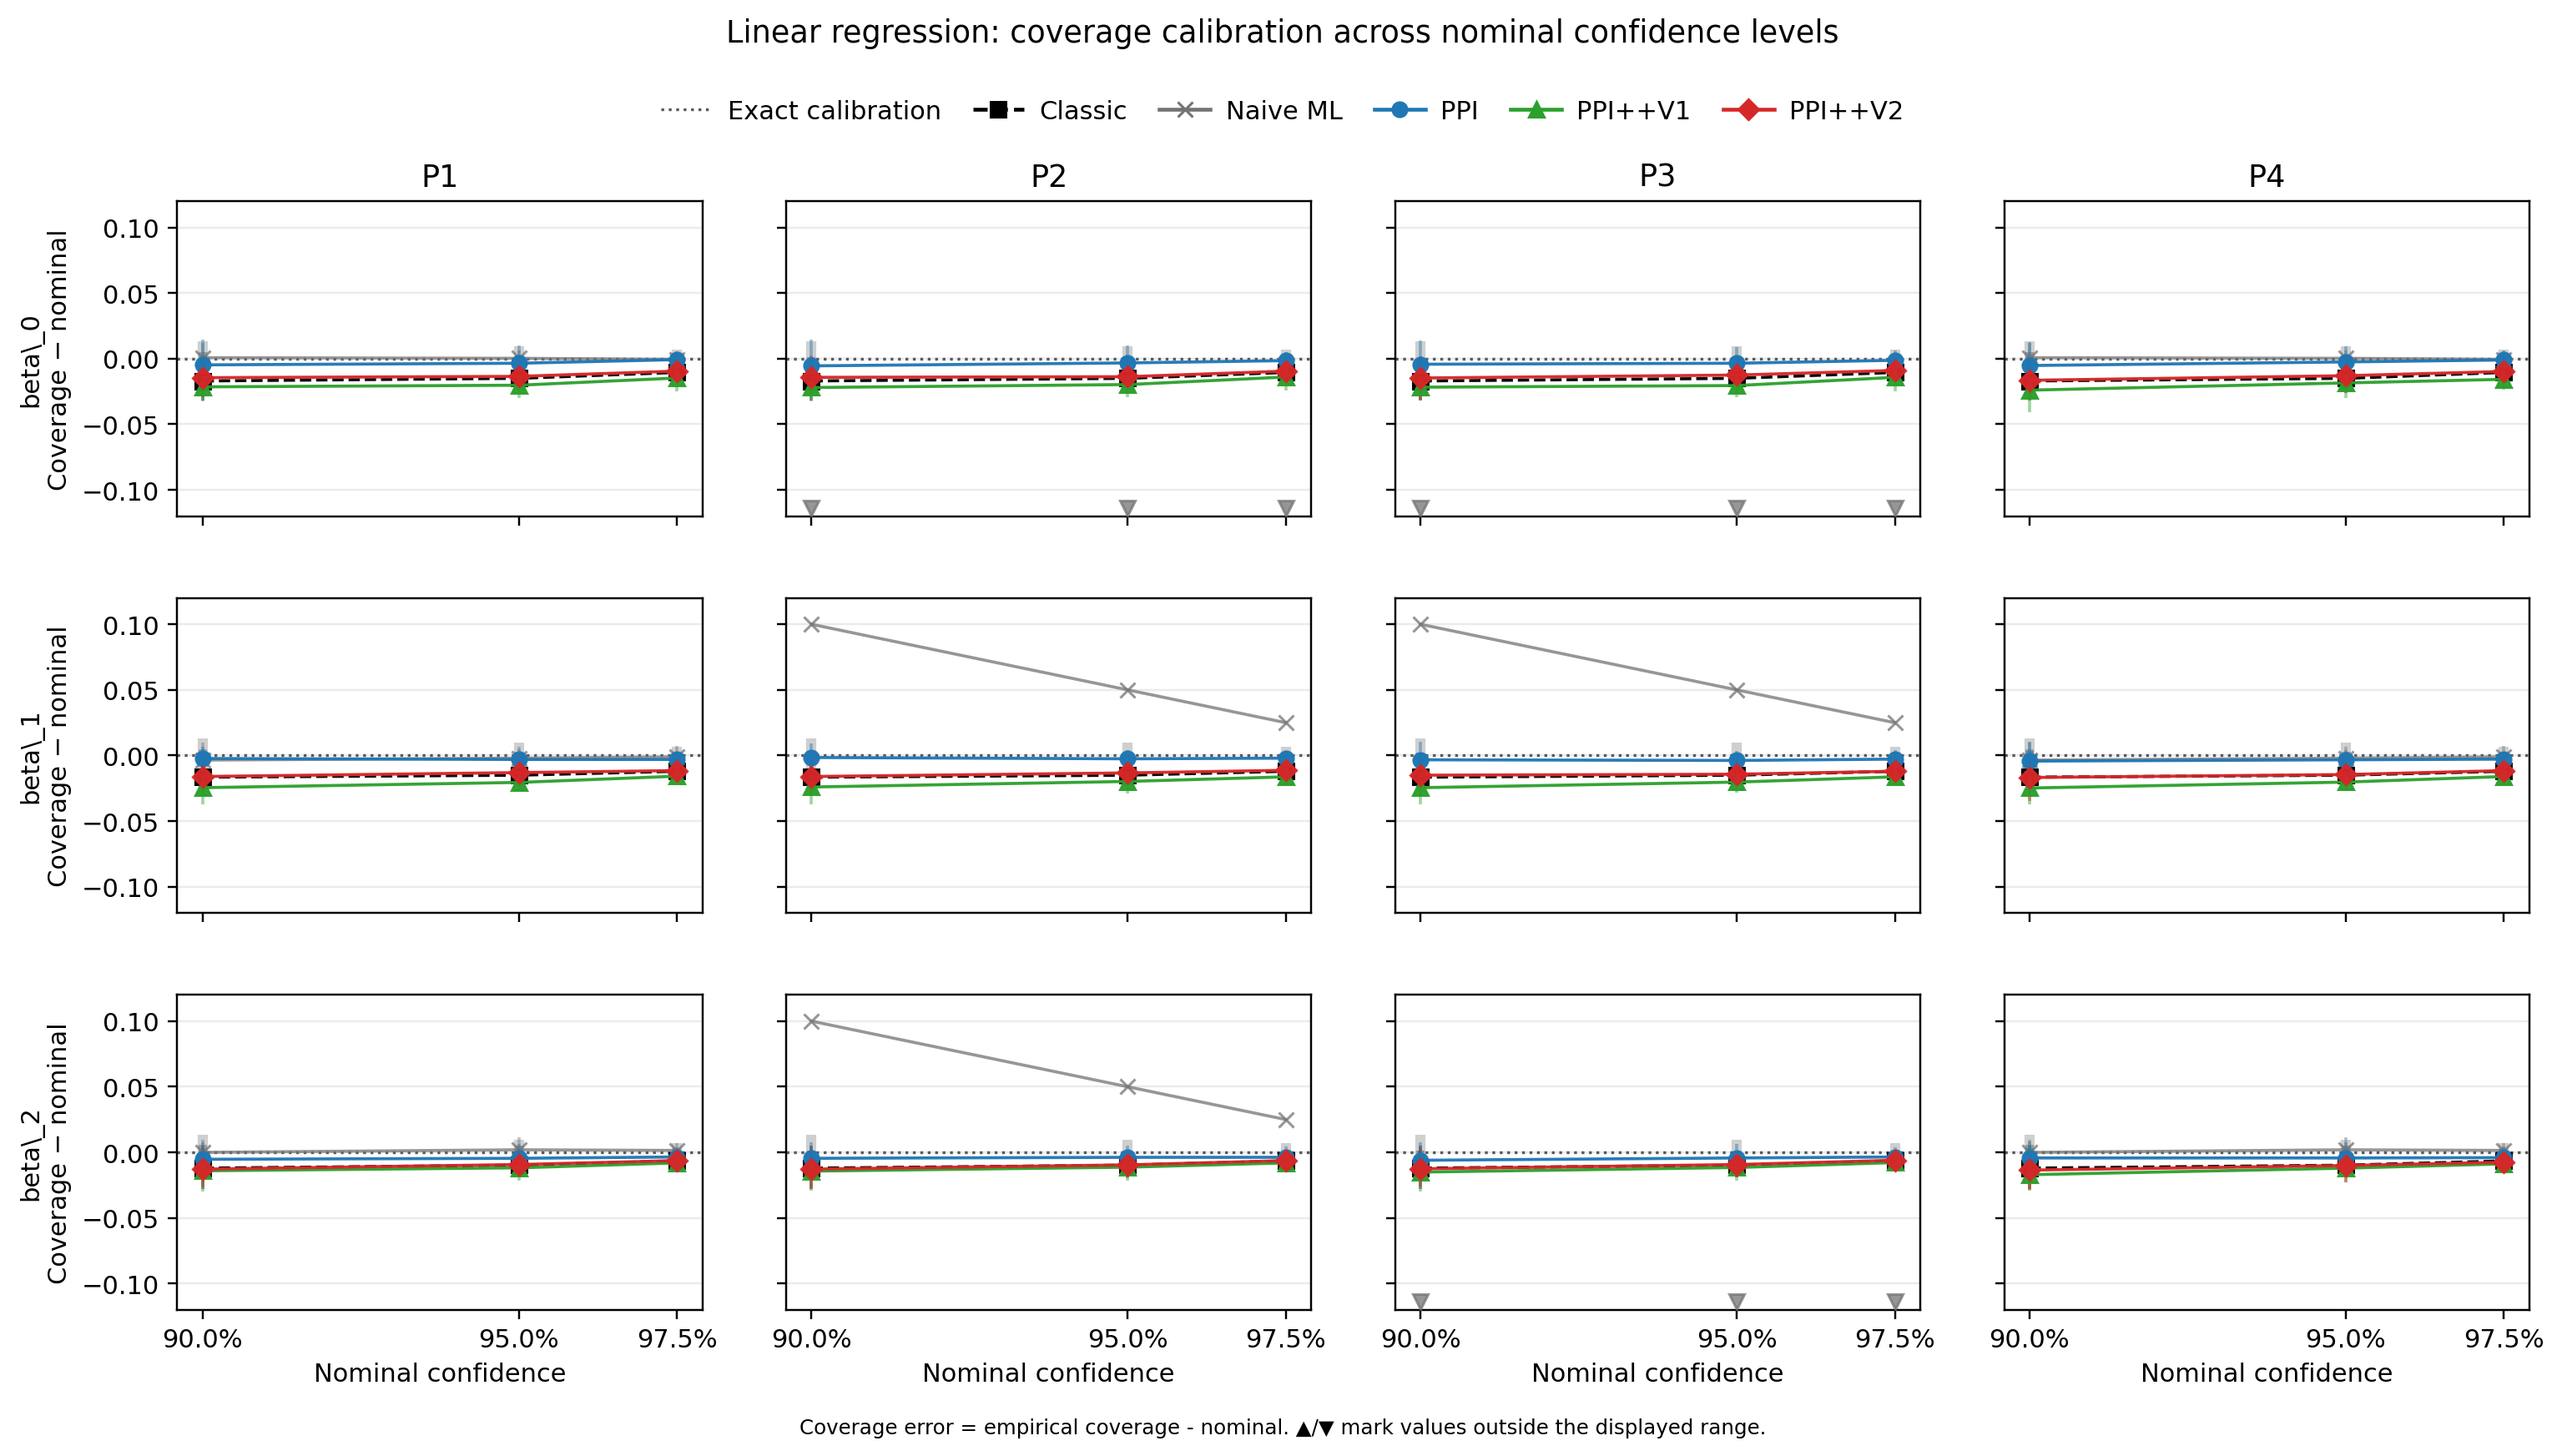

#### mean_calibration.png

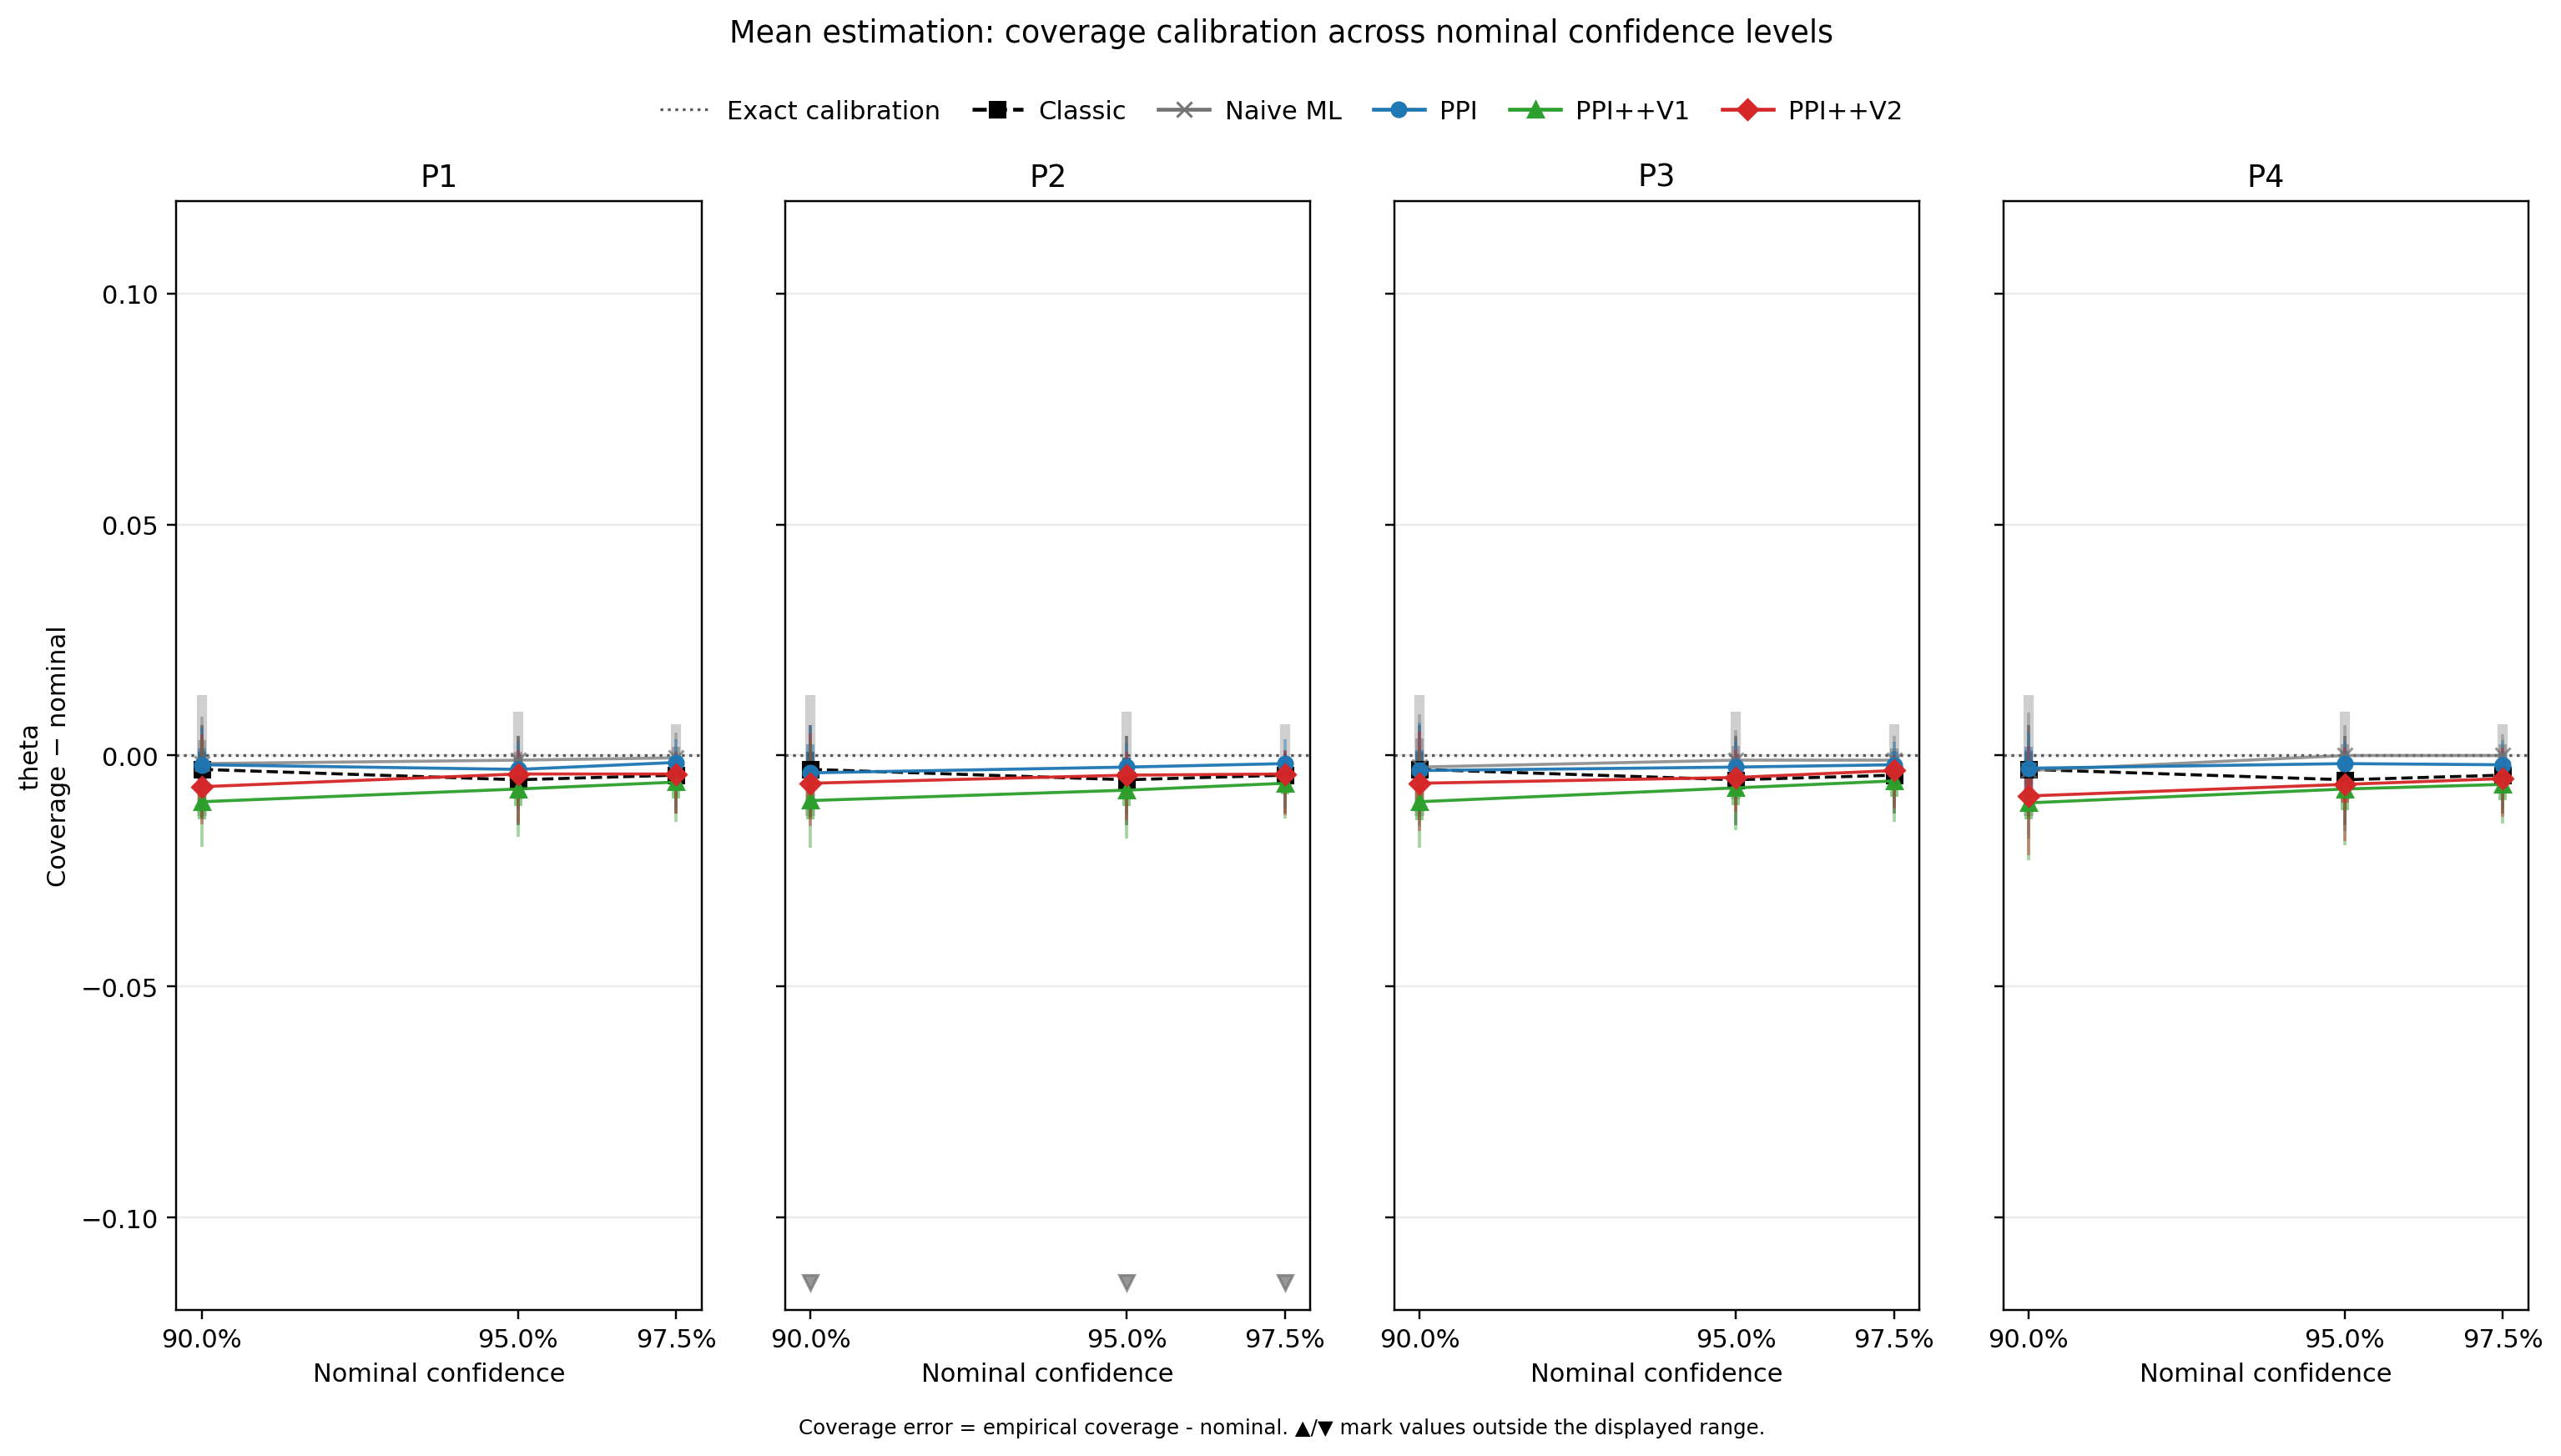

In [3]:
fig_dir = OUT / "figure"

if fig_dir.exists():
    figures = sorted([
        p for p in fig_dir.iterdir()
        if p.suffix.lower() in [".png", ".jpg", ".jpeg", ".svg"]
    ])
    cal_figs = [p for p in figures if "calibration" in p.name]

    if not cal_figs:
        display(Markdown("No calibration figures found."))

    for p in cal_figs:
        display(Markdown(f"#### {p.name}"))
        if p.suffix.lower() == ".svg":
            display(Markdown(f"[Open figure]({p.as_posix()})"))
        else:
            display(Image(filename=str(p)))
else:
    display(Markdown("No figure directory found."))


### 5.3 Result Tables

#### Main 95% numerical summary


In [4]:
table_dir = OUT / "table"
other_dir = OUT / "other"


def _first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None


def _round_numeric(df, digits=4):
    out = df.copy()
    num_cols = out.select_dtypes(include="number").columns
    out[num_cols] = out[num_cols].round(digits)
    return out


def _filter_95(df):
    out = df.copy()
    cl_candidates = ["confidence_level", "conf_level", "level", "cl"]
    cl_col = next((c for c in cl_candidates if c in out.columns), None)
    if cl_col is None:
        return out

    s = out[cl_col]
    s_str = s.astype(str).str.lower()
    mask = (
        s_str.isin(["0.95", "95", "950", "cl_950", "95%", "0.950"])
        | s_str.str.contains("950", regex=False)
    )
    s_num = pd.to_numeric(s, errors="coerce")
    mask = mask | s_num.isin([0.95, 95, 950])
    return out.loc[mask].copy() if mask.any() else out


def _select_existing_columns(df, candidates):
    return [c for c in candidates if c in df.columns]


def _apply_display_labels(df):
    out = df.copy()
    if "method_label" not in out.columns and "method" in out.columns:
        out["method_label"] = out["method"].map(METHOD_LABELS).fillna(out["method"])
    if "scenario" in out.columns:
        out["scenario"] = out["scenario"].map(SCENARIO_LABELS).fillna(out["scenario"])
    return out


main_table_priority = [
    table_dir / "plot_summary.csv",
    table_dir / "seed0_metrics.csv",
    table_dir / "metrics_seed0.csv",
]
main_path = _first_existing(main_table_priority)

main_cols = [
    "scenario",
    "profile",
    "target",
    "parameter",
    "method",
    "method_label",
    "coverage",
    "empirical_coverage",
    "coverage_error",
    "center_coverage_error",
    "avg_width",
    "average_width",
    "average_ci_width",
    "ci_width",
    "relative_width",
    "rel_width",
    "center_relative_ci_width",
]

if main_path is None:
    display(Markdown("No main result table found."))
else:
    try:
        main_df = pd.read_csv(main_path)
        main_df = _apply_display_labels(_filter_95(main_df))
        cols = _select_existing_columns(main_df, main_cols)
        if "method" in cols and "method_label" in cols:
            cols.remove("method")
        main_show = main_df[cols].copy() if cols else main_df.copy()
        main_show = _round_numeric(main_show)
        display(Markdown(
            f"Source table: `{main_path.name}`. "
            "The table is filtered to the 95% confidence level when the confidence-level column is available."
        ))
        display(main_show.head(60))
    except Exception as e:
        display(Markdown(f"Could not read `{main_path.name}`: `{e}`"))


Source table: `plot_summary.csv`. The table is filtered to the 95% confidence level when the confidence-level column is available.

,scenario,profile,target,method_label,center_coverage_error,center_relative_ci_width
1,Logistic GLM,P1,beta_0,Naive ML,0.0002,0.0029
4,Logistic GLM,P1,beta_0,PPI,0.0198,1.0104
7,Logistic GLM,P1,beta_0,PPI++V1,0.0015,0.9928
10,Logistic GLM,P1,beta_0,PPI++V2,0.0075,0.9682
13,Logistic GLM,P2,beta_0,Naive ML,-0.9500,0.0037
16,Logistic GLM,P2,beta_0,PPI,0.0202,1.0132
19,Logistic GLM,P2,beta_0,PPI++V1,0.0025,0.9923
22,Logistic GLM,P2,beta_0,PPI++V2,0.0075,0.9727
25,Logistic GLM,P3,beta_0,Naive ML,-0.9500,0.0021
28,Logistic GLM,P3,beta_0,PPI,0.0205,1.0187


#### PPI++V2 selected lambda


In [5]:
lambda_paths = [
    other_dir / "diagnostics_seed0.parquet",
    other_dir / "diagnostics_seed0.csv.gz",
    table_dir / "plot_summary.csv",
]
lambda_path = _first_existing(lambda_paths)

lambda_candidates = [
    "selected_lambda",
    "lambda_hat",
    "lambda",
    "lambda_",
    "lambda_median",
    "lambda_iqr",
    "lambda_min",
    "lambda_max",
]

if lambda_path is None:
    display(Markdown("No lambda diagnostic table found."))
else:
    try:
        if lambda_path.suffix == ".parquet":
            lambda_df = pd.read_parquet(lambda_path)
        else:
            lambda_df = pd.read_csv(lambda_path)

        if "method_label" not in lambda_df.columns and "method" in lambda_df.columns:
            lambda_df["method_label"] = lambda_df["method"].map(METHOD_LABELS).fillna(lambda_df["method"])

        mask = pd.Series(False, index=lambda_df.index)
        if "method" in lambda_df.columns:
            mask = mask | lambda_df["method"].eq("ppi_plus_plus_v2")
        if "method_label" in lambda_df.columns:
            mask = mask | lambda_df["method_label"].eq("PPI++V2")
        lambda_df = lambda_df.loc[mask].copy()

        lambda_col = next((c for c in lambda_candidates if c in lambda_df.columns), None)
        if lambda_df.empty or lambda_col is None:
            display(Markdown("No PPI++V2 selected-lambda values found."))
        else:
            lambda_df[lambda_col] = pd.to_numeric(lambda_df[lambda_col], errors="coerce")
            group_cols = [c for c in ["scenario", "profile", "target", "parameter"] if c in lambda_df.columns]
            if group_cols:
                lambda_show = (
                    lambda_df.dropna(subset=[lambda_col])
                    .groupby(group_cols, as_index=False)
                    .agg(
                        lambda_median=(lambda_col, "median"),
                        lambda_iqr=(lambda_col, lambda x: x.quantile(0.75) - x.quantile(0.25)),
                        lambda_min=(lambda_col, "min"),
                        lambda_max=(lambda_col, "max"),
                    )
                )
            else:
                values = lambda_df[lambda_col].dropna()
                lambda_show = pd.DataFrame({
                    "lambda_median": [values.median()],
                    "lambda_iqr": [values.quantile(0.75) - values.quantile(0.25)],
                    "lambda_min": [values.min()],
                    "lambda_max": [values.max()],
                })
            if "scenario" in lambda_show.columns:
                lambda_show["scenario"] = lambda_show["scenario"].map(SCENARIO_LABELS).fillna(lambda_show["scenario"])
            display(Markdown(f"Source table: `{lambda_path.relative_to(OUT)}`."))
            display(_round_numeric(lambda_show, digits=4))
    except Exception as e:
        display(Markdown(f"Could not read `{lambda_path.name}`: `{e}`"))


Source table: `other\diagnostics_seed0.parquet`.

,scenario,profile,lambda_median,lambda_iqr,lambda_min,lambda_max
0,Logistic GLM,P1,0.400,0.525,0.000,1.0
1,Logistic GLM,P2,0.350,0.500,0.000,1.0
2,Logistic GLM,P3,0.375,0.525,0.000,1.0
3,Logistic GLM,P4,0.375,0.525,0.000,1.0
4,Linear regression,P1,0.375,0.600,0.000,1.0
5,Linear regression,P2,0.375,0.625,0.000,1.0
6,Linear regression,P3,0.375,0.600,0.000,1.0
7,Linear regression,P4,0.300,0.500,0.000,1.0
8,Mean estimation,P1,0.900,0.225,0.275,1.0
9,Mean estimation,P2,0.900,0.225,0.275,1.0


## 6. Raw Output Files

The files below are kept for audit and reproducibility. They are not expanded in the notebook because the main result display above already extracts the columns needed for interpretation.


In [6]:
raw_specs = [
    ("table/seed0_metrics.csv", "Seed-0 aggregate metrics for full-mode output."),
    ("table/metrics_seed0.csv", "Seed-0 aggregate metrics for fast-mode output."),
    ("table/all_seed_metrics.csv", "Complete seed-level metrics."),
    ("table/robustness_summary.csv", "Robustness summary across outer seeds."),
    ("table/plot_summary.csv", "Exact aggregate quantities used for plotting."),
    ("other/diagnostics_seed0.parquet", "Convergence, Hessian condition number, and PPI++V1/PPI++V2 diagnostics."),
    ("other/diagnostics_seed0.csv.gz", "Compressed fallback for diagnostics."),
    ("other/replicate_results_seed0.parquet", "Interval-level replicate audit records."),
    ("other/replicate_results_seed0.csv.gz", "Compressed fallback for replicate-level audit records."),
]

rows = []
for rel, purpose in raw_specs:
    p = OUT / rel
    rows.append({
        "File": rel,
        "Exists": p.exists(),
        "Purpose": purpose,
    })

display(pd.DataFrame(rows))


,File,Exists,Purpose
0,table/seed0_metrics.csv,True,Seed-0 aggregate metrics for full-mode output.
1,table/metrics_seed0.csv,False,Seed-0 aggregate metrics for fast-mode output.
2,table/all_seed_metrics.csv,True,Complete seed-level metrics.
3,table/robustness_summary.csv,True,Robustness summary across outer seeds.
4,table/plot_summary.csv,True,Exact aggregate quantities used for plotting.
5,other/diagnostics_seed0.parquet,True,"Convergence, Hessian condition number, and PPI..."
6,other/diagnostics_seed0.csv.gz,False,Compressed fallback for diagnostics.
7,other/replicate_results_seed0.parquet,True,Interval-level replicate audit records.
8,other/replicate_results_seed0.csv.gz,False,Compressed fallback for replicate-level audit ...
